<a href="https://colab.research.google.com/github/Edenshmuel/CrimeData/blob/main/Anomaly_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Importing Required Libraries

!pip install *py7zr*

In [1]:
!pip install py7zr

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.3/71.3 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 494.2/494.2 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.6/100.6 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.3/144.3 kB 4.8 MB/s eta 0:00:00


In [2]:
import pandas as pd
import seaborn as sns
from matplotlib import rcParams
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

Loading and Extracting Unupervised Datasets from GitHub Repository

In [3]:
import os
import py7zr
import pandas as pd

# Install library for 7z extraction
!pip install py7zr

# Clone the dataset repository from GitHub
!git clone https://github.com/Edenshmuel/CrimeData.git

zip_folder = 'CrimeData'

# Define paths to the 7z file
archive_files = [os.path.join(zip_folder, 'Clean_data_unsupervised.7z')]
extracted_folders = []

# Extract 7z files if they exist and were not previously extracted
for archive_file in archive_files:
    extract_path = archive_file.replace('.7z', '')

    if os.path.exists(archive_file):
        if not os.path.exists(extract_path):
            with py7zr.SevenZipFile(archive_file, mode='r') as z:
                z.extractall(path=extract_path)
            print(f"Extracted: {archive_file} -> {extract_path}")
        else:
            print(f"Skipped: {archive_file} (Already extracted)")
    else:
        print(f"File not found: {archive_file}")

    extracted_folders.append(extract_path)

dataframes = []

# Load all CSV files from the extracted folders
for folder in extracted_folders:
    for file_name in os.listdir(folder):
        file_path = os.path.join(folder, file_name)
        if file_name.endswith('.csv'):
            df_temp = pd.read_csv(file_path)
            dataframes.append(df_temp)

combined_df = pd.concat(dataframes, ignore_index=True)

# Display dataset summary
print(f"Combined dataset contains {combined_df.shape[0]} rows and {combined_df.shape[1]} columns.")

Cloning into 'CrimeData'...
remote: Enumerating objects: 1172, done.
remote: Counting objects: 100% (303/303), done.
remote: Compressing objects: 100% (122/122), done.
remote: Total 1172 (delta 260), reused 181 (delta 181), pack-reused 869 (from 2)
Receiving objects: 100% (1172/1172), 447.61 MiB | 39.76 MiB/s, done.
Resolving deltas: 100% (621/621), done.
Extracted: CrimeData/Clean_data_unsupervised.7z -> CrimeData/Clean_data_unsupervised
Combined dataset contains 2196247 rows and 19 columns.


In [4]:
def reverse_hebrew_text(text):
    return text[::-1]

Correlation Heatmap with Hebrew Support

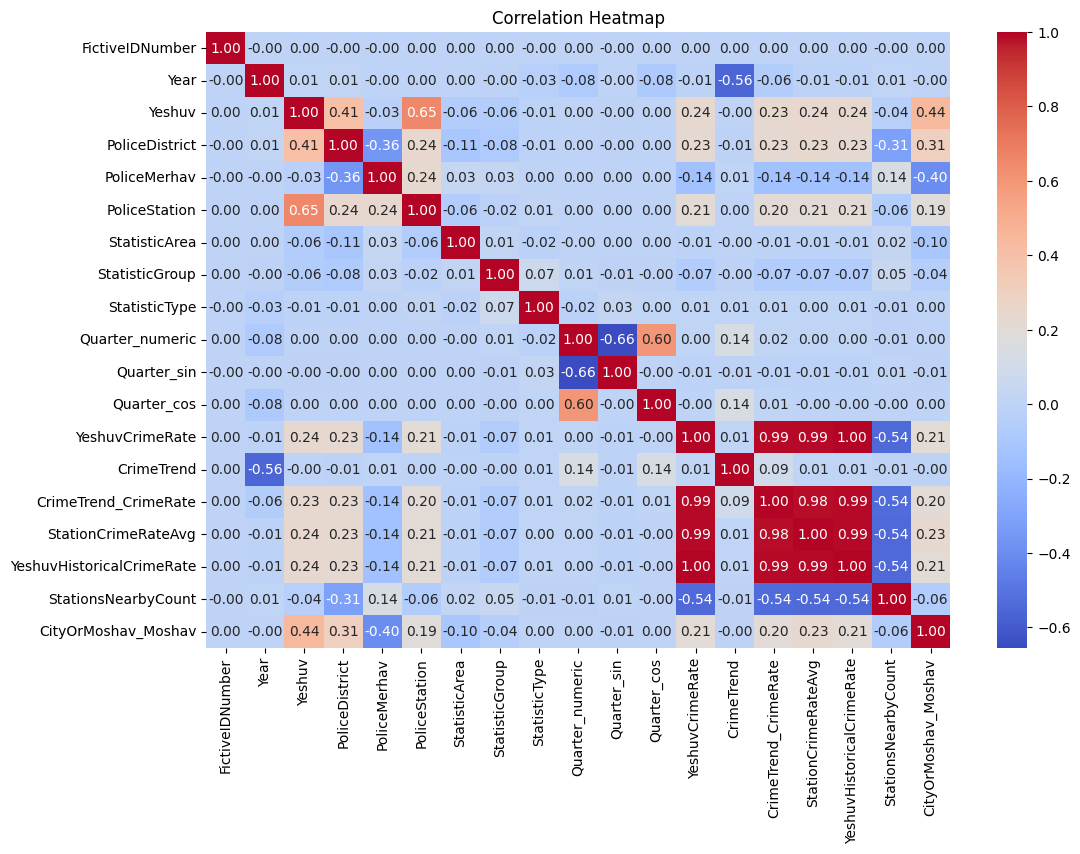

In [5]:
# Calculate correlation matrix for numerical variables
correlation_matrix = combined_df.corr()

# Create a heatmap to visualize correlations
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

Grouping by 'Yeshuv' and Calculating Metrics

In [6]:
# Aggregate data by 'Yeshuv' for crime rates, nearby stations, and crime trends
yeshuv_grouped = combined_df.groupby('Yeshuv').agg(
    YeshuvCrimeRateAvg=('YeshuvCrimeRate', 'mean'),
    StationsNearbyAvg=('StationsNearbyCount', 'mean'),
    CrimeTrendAvg=('CrimeTrend', 'mean')).reset_index()

# Normalize the crime rate by the average number of nearby stations
yeshuv_grouped['CrimeRateNormalized'] = (
    yeshuv_grouped['YeshuvCrimeRateAvg'] / yeshuv_grouped['StationsNearbyAvg'])

Sorting Localities by Crime Rate and Number of Stations

In [7]:
# Sort localities by descending crime rate and ascending number of stations
sorted_yeshuv = yeshuv_grouped.sort_values(
    by=['YeshuvCrimeRateAvg', 'StationsNearbyAvg'], ascending=[False, True])

# Display the top 10 localities with high crime rates and few stations
print("Top 10 Localities with Highest Crime Rate and Few Stations:")
print(sorted_yeshuv.head(10))

Top 10 Localities with Highest Crime Rate and Few Stations:
     Yeshuv  YeshuvCrimeRateAvg  StationsNearbyAvg  CrimeTrendAvg  \
112     112            2.384437           2.000010       4.960312   
47       47            2.213131           1.332403       5.043979   
13       13            1.122626           3.000010       4.993315   
36       36            0.916695           2.333343       5.036346   
10       10            0.637193           3.000010       4.940150   
101     101            0.606069           2.666677       4.935848   
85       85            0.585271           2.666474       4.999976   
74       74            0.570258           2.666677       4.979805   
11       11            0.503840           3.000010       4.927345   
35       35            0.474503           2.000154       4.898248   

     CrimeRateNormalized  
112             1.192213  
47              1.661007  
13              0.374207  
36              0.392868  
10              0.212397  
101             0.

Identifying Priority Localities Based on Crime Rate and Station Count

In [8]:
# Define thresholds for high crime rate and low station count
high_crime_threshold = yeshuv_grouped['YeshuvCrimeRateAvg'].mean()
low_station_threshold = yeshuv_grouped['StationsNearbyAvg'].mean()

# Filter priority localities
priority_yeshuvs = yeshuv_grouped[
    (yeshuv_grouped['YeshuvCrimeRateAvg'] > high_crime_threshold) &
    (yeshuv_grouped['StationsNearbyAvg'] < low_station_threshold)]

Loading Mapping Data and Merging with Priority Localities

In [9]:
# Define the path to the mapping file
mapping_file_path = os.path.join(zip_folder, 'Yeshuv_mapping_unsupervised.csv')

# Load the mapping file if it exists
if os.path.exists(mapping_file_path):
    mapping_data = pd.read_csv(mapping_file_path)
else:
    raise FileNotFoundError(f"Mapping file not found at {mapping_file_path}")


In [10]:
# Merge priority localities with the mapping data to retrieve locality names
priority_yeshuvs_with_names = pd.merge(
    priority_yeshuvs,
    mapping_data,
    left_on='Yeshuv',
    right_on='Encoded_Value',
    how='left')

Ensuring Correct Column Selection and Renaming for Priority Localities

In [11]:
# Select relevant columns and ensure proper naming
priority_yeshuvs_with_names = priority_yeshuvs_with_names[
    ['YeshuvCrimeRateAvg', 'StationsNearbyAvg', 'CrimeTrendAvg',
     'CrimeRateNormalized', 'Encoded_Value', 'Yeshuv_y']
].rename(columns={'Yeshuv_y': 'Locality_Name'})

priority_yeshuvs_with_names

,YeshuvCrimeRateAvg,StationsNearbyAvg,CrimeTrendAvg,CrimeRateNormalized,Encoded_Value,Locality_Name
0,0.201418,1.333343,4.964506,0.151062,15,בית שמש
1,0.244294,2.000010,4.912690,0.122147,17,בני ברק
2,0.470506,2.001917,4.908714,0.235028,19,בת ים
3,0.254956,2.000010,4.974372,0.127477,32,הרצליה
4,0.291799,2.333343,5.025491,0.125056,34,חדרה
5,0.474503,2.000154,4.898248,0.237233,35,חולון
6,0.916695,2.333343,5.036346,0.392868,36,חיפה
7,2.213131,1.332403,5.043979,1.661007,47,ירושלים
8,0.223066,2.333343,5.083408,0.095599,77,עכו
9,0.362884,2.000010,4.917527,0.181441,106,רמת גן


Assigning Priority Levels and Visualizing Localities

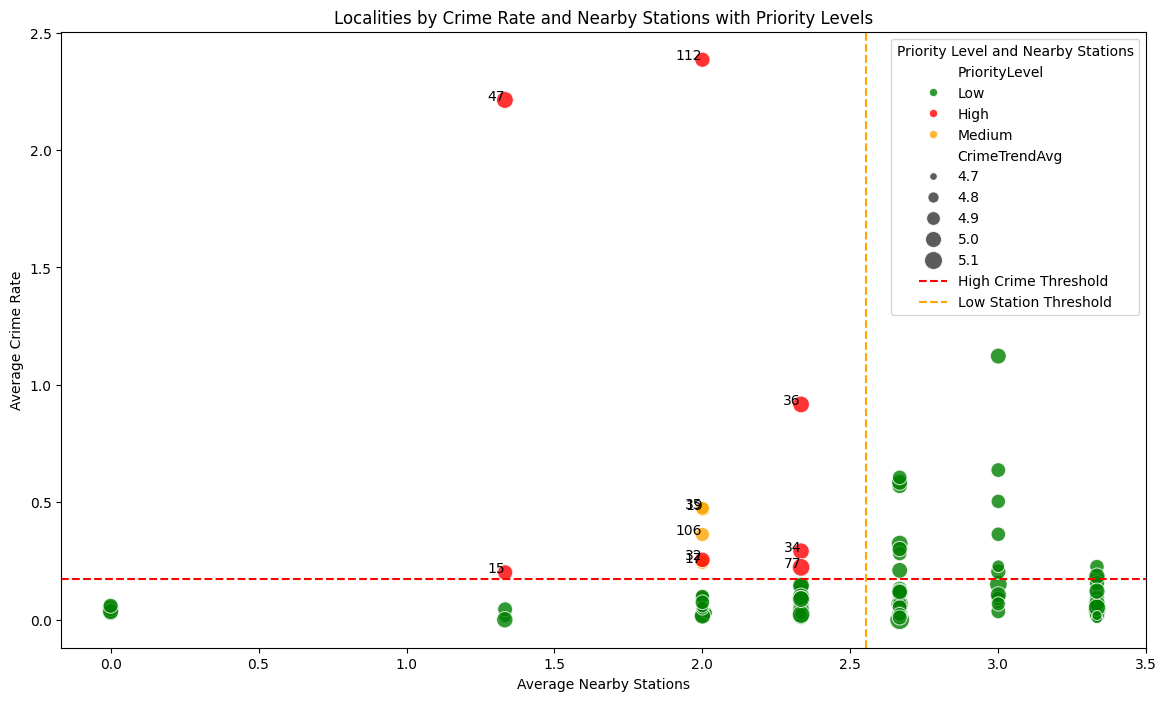

In [12]:
# Define threshold for high crime trend
high_trend_threshold = yeshuv_grouped['CrimeTrendAvg'].mean()

# Default priority
yeshuv_grouped['PriorityLevel'] = 'Low'

# Masks
high_mask = (
    (yeshuv_grouped['YeshuvCrimeRateAvg'] > high_crime_threshold) &
    (yeshuv_grouped['StationsNearbyAvg'] < low_station_threshold) &
    (yeshuv_grouped['CrimeTrendAvg'] > high_trend_threshold)
)

medium_mask = (
    (yeshuv_grouped['YeshuvCrimeRateAvg'] > high_crime_threshold) &
    (yeshuv_grouped['StationsNearbyAvg'] < low_station_threshold) &
    (~high_mask)
)

# Assign priority levels
yeshuv_grouped.loc[high_mask, 'PriorityLevel'] = 'High'
yeshuv_grouped.loc[medium_mask, 'PriorityLevel'] = 'Medium'

# Define color mapping for priority levels
priority_colors = {
    'High': 'red',
    'Medium': 'orange',
    'Low': 'green'
}

# === Creating a Scatter Plot for Localities by Priority Level ===
plt.figure(figsize=(14, 8))
sns.scatterplot(
    x=yeshuv_grouped['StationsNearbyAvg'],
    y=yeshuv_grouped['YeshuvCrimeRateAvg'],
    hue=yeshuv_grouped['PriorityLevel'],
    size=yeshuv_grouped['CrimeTrendAvg'],
    sizes=(20, 200),
    palette=priority_colors,
    alpha=0.8
)

# Add threshold lines for better visualization
plt.axhline(high_crime_threshold, color='red', linestyle='--', label='High Crime Threshold')
plt.axvline(low_station_threshold, color='orange', linestyle='--', label='Low Station Threshold')

# Annotate points with high and medium priority using Hebrew support
for index, row in yeshuv_grouped.iterrows():
    if row['PriorityLevel'] in ['High', 'Medium']:
        plt.text(row['StationsNearbyAvg'], row['YeshuvCrimeRateAvg'], row['Yeshuv'],
                 fontsize=10, ha='right')

# Titles and labels
plt.title("Localities by Crime Rate and Nearby Stations with Priority Levels")
plt.xlabel("Average Nearby Stations")
plt.ylabel("Average Crime Rate")
plt.legend(title="Priority Level and Nearby Stations")
plt.show()


*Yellow dots are flagged as high-priority targets for increasing police station coverage or other interventions to reduce crime.
We're continuing our analysis focusing in these localities.*


Visualizing Crime Rate and Station Relationships with RTL Support

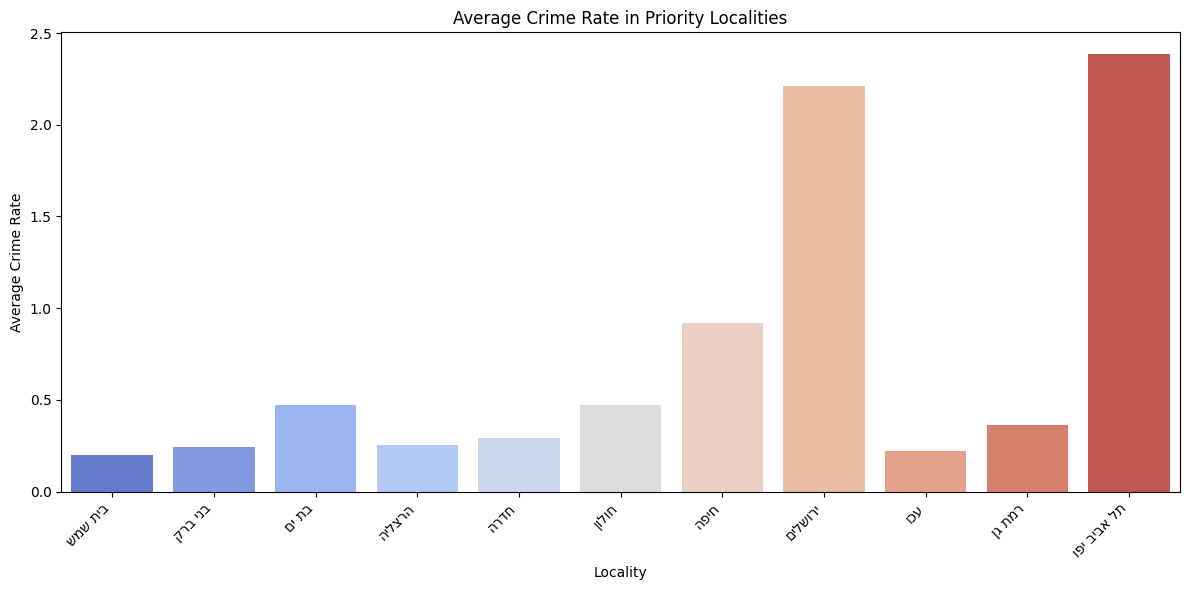

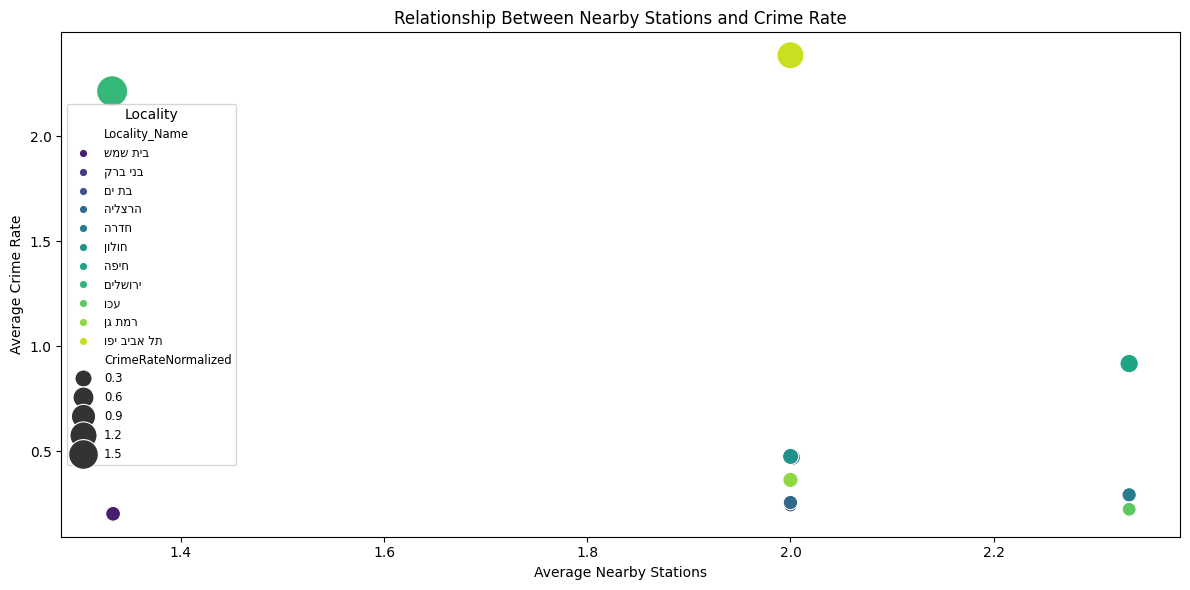

In [13]:
# Ensure Right-to-Left (RTL) support and proper Hebrew rendering
rcParams['text.usetex'] = False  # Disable LaTeX for better compatibility with Hebrew
rcParams['font.family'] = 'DejaVu Sans'  # Set a font supporting Hebrew characters

# Reverse Hebrew text for locality names for proper RTL display
priority_yeshuvs_with_names['Locality_Name'] = priority_yeshuvs_with_names['Locality_Name'].apply(reverse_hebrew_text)

# === Bar Plot: Average Crime Rate in Priority Localities ===
plt.figure(figsize=(12, 6))
sns.barplot(
    data=priority_yeshuvs_with_names,
    x='Locality_Name',
    y='YeshuvCrimeRateAvg',
    hue='Locality_Name',  # Assign hue explicitly to match bars with localities
    palette='coolwarm',
    dodge=False)  # Prevent multiple bars for the same locality

plt.title("Average Crime Rate in Priority Localities", loc='center')
plt.xlabel("Locality")
plt.ylabel("Average Crime Rate")
plt.xticks(rotation=45, horizontalalignment='right')
plt.legend([], [], frameon=False)  # Hide legend if unnecessary
plt.tight_layout()
plt.show()

# === Scatter Plot: Relationship Between Nearby Stations and Crime Rate ===
plt.figure(figsize=(12, 6))
scatter = sns.scatterplot(
    data=priority_yeshuvs_with_names,
    x='StationsNearbyAvg',
    y='YeshuvCrimeRateAvg',
    size='CrimeRateNormalized',
    hue='Locality_Name',
    sizes=(100, 500),
    palette='viridis')

# Customize the legend for better readability
handles, labels = scatter.get_legend_handles_labels()
plt.legend(handles, labels, title="Locality", loc='best', fontsize='small')

plt.title("Relationship Between Nearby Stations and Crime Rate", loc='center')
plt.xlabel("Average Nearby Stations")
plt.ylabel("Average Crime Rate")
plt.tight_layout()
plt.show()

Training Isolation Forest for Anomaly Detection

In [14]:
# Initialize the Isolation Forest model with specified contamination level
isolation_forest = IsolationForest(contamination=0.1, random_state=42)

# Fit the model and predict anomalies based on crime rate and station count
priority_yeshuvs_with_names['Anomaly'] = isolation_forest.fit_predict(
    priority_yeshuvs_with_names[['YeshuvCrimeRateAvg', 'StationsNearbyAvg']])

Anomaly Detection Using Isolation Forest and Local Outlier Factor (LOF)

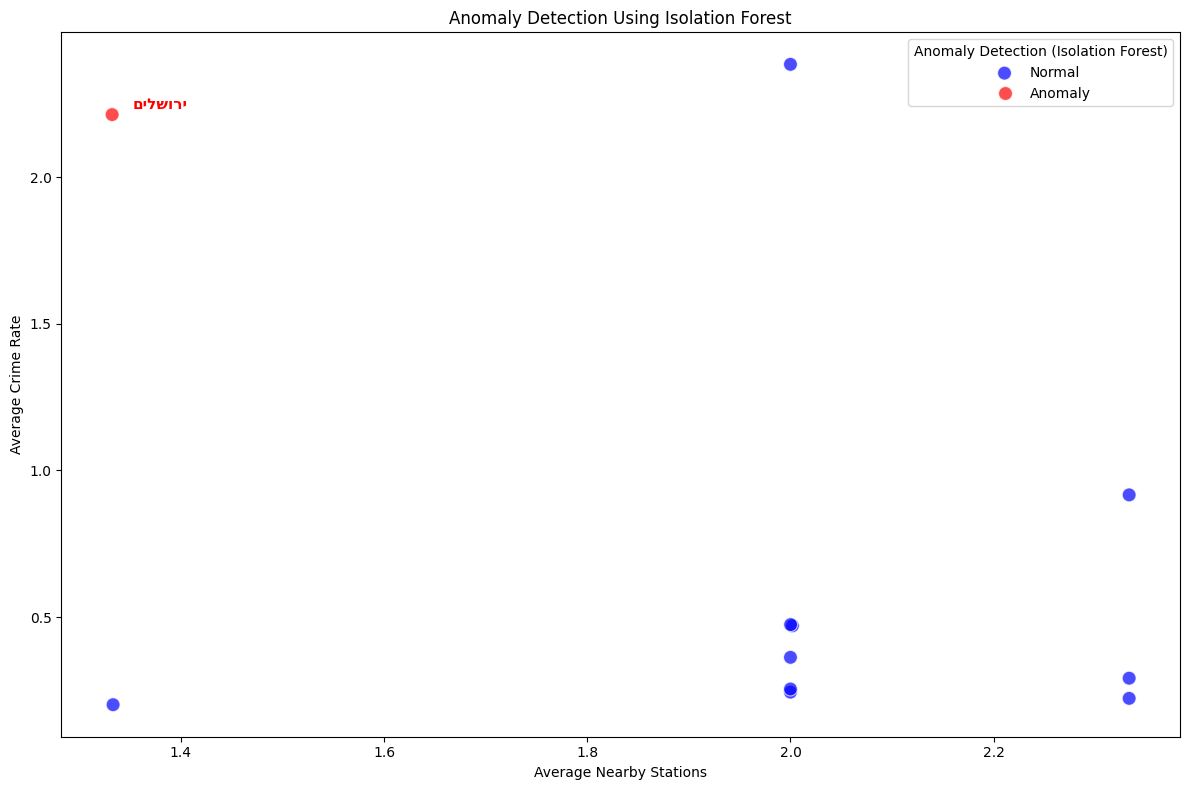

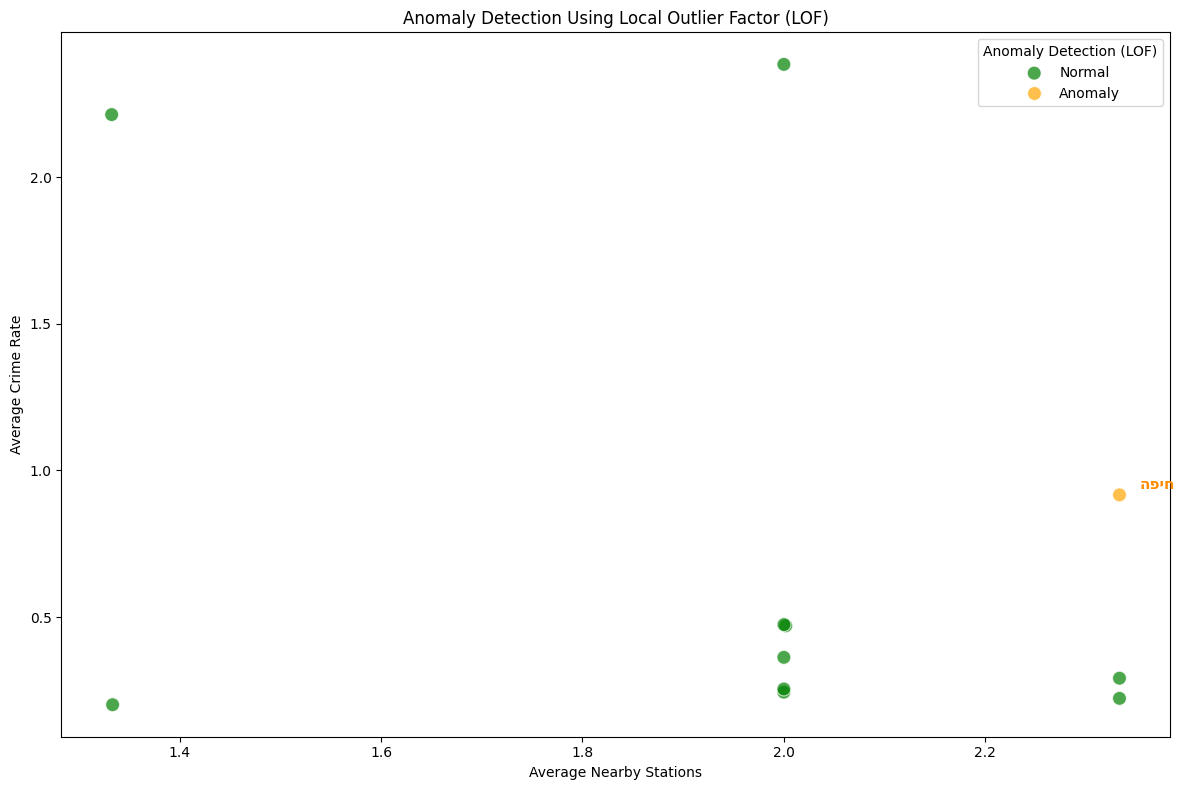

In [15]:
# Set font for Hebrew compatibility
plt.rcParams['font.family'] = 'DejaVu Sans'

# Step 1: Anomaly Detection with Isolation Forest
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x=priority_yeshuvs_with_names['StationsNearbyAvg'],
    y=priority_yeshuvs_with_names['YeshuvCrimeRateAvg'],
    hue=priority_yeshuvs_with_names['Anomaly'],  # -1 for anomalies, 1 for normal
    palette={-1: 'red', 1: 'blue'},
    s=100,
    alpha=0.7)
for i, row in priority_yeshuvs_with_names.iterrows():
    if row['Anomaly'] == -1:  # רק אנומליות
        plt.text(
            row['StationsNearbyAvg'] + 0.02,
            row['YeshuvCrimeRateAvg'] + 0.02,
            row['Locality_Name'],
            fontsize=11,
            color='red',
            weight='bold')

plt.title("Anomaly Detection Using Isolation Forest")
plt.xlabel("Average Nearby Stations")
plt.ylabel("Average Crime Rate")
plt.legend(title="Anomaly Detection (Isolation Forest)", labels=["Normal", "Anomaly"])
plt.tight_layout()
plt.show()

# Step 2: Anomaly Detection with Local Outlier Factor (LOF)
from sklearn.neighbors import LocalOutlierFactor

# Adjust number of neighbors dynamically based on dataset size
n_neighbors = min(20, len(priority_yeshuvs_with_names) - 1)

# Train LOF model for anomaly detection
lof = LocalOutlierFactor(n_neighbors=n_neighbors, contamination=0.1)
priority_yeshuvs_with_names['Anomaly_LOF'] = lof.fit_predict(
    priority_yeshuvs_with_names[['YeshuvCrimeRateAvg', 'StationsNearbyAvg']])

# Scatter plot for LOF anomaly detection results
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x=priority_yeshuvs_with_names['StationsNearbyAvg'],
    y=priority_yeshuvs_with_names['YeshuvCrimeRateAvg'],
    hue=priority_yeshuvs_with_names['Anomaly_LOF'],  # -1 for anomalies, 1 for normal
    palette={-1: 'orange', 1: 'green'},
    s=100,
    alpha=0.7)
for i, row in priority_yeshuvs_with_names.iterrows():
    if row['Anomaly_LOF'] == -1:  # רק אנומליות
        plt.text(
            row['StationsNearbyAvg'] + 0.02,
            row['YeshuvCrimeRateAvg'] + 0.02,
            row['Locality_Name'],
            fontsize=11,
            color='darkorange',
            weight='bold')

plt.title("Anomaly Detection Using Local Outlier Factor (LOF)")
plt.xlabel("Average Nearby Stations")
plt.ylabel("Average Crime Rate")
plt.legend(title="Anomaly Detection (LOF)", labels=["Normal", "Anomaly"])
plt.tight_layout()
plt.show()